**Fairuz Bilquis Khan**

The dataset combines two Defects4J projects:
- **Lang**: ~2,200 methods across 60 bug versions
- **Math**: ~1,600 methods across 106 bug versions
- **Combined**: 3,872 methods


## Setup

In [389]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
)

# Plotting defaults
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# Output directory for figures
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
ESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Random seed
SEED = 42
np.random.seed(SEED)

## 1. Loading the Dataset

Load the merged Lang + Math dataset built by `build_dataset.py`.

In [390]:
DATA_PATH = "new_dataset.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head(3)

Loaded 3872 rows, 43 columns


,method_id,project,bug_id,version_key,class_fqn,method_name,start_line,end_line,loc,num_params,...,mutation_score,frac_ROR,frac_AOR,frac_LOR,frac_COR,frac_SOR,frac_ORU,frac_LVR,frac_STD,mutation_score_bin
0,Lang-49f_org.apache.commons.lang.math.Fraction...,Lang,49,Lang-49f,org.apache.commons.lang.math.Fraction,getFraction,141,154,10,2,...,0.791667,0.416667,0.000000,0.000000,0.166667,0.0,0.166667,0.166667,0.083333,medium
1,Lang-49f_org.apache.commons.lang.math.Fraction...,Lang,49,Lang-49f,org.apache.commons.lang.math.Fraction,getFraction,172,193,16,3,...,0.866667,0.400000,0.355556,0.000000,0.066667,0.0,0.000000,0.177778,0.000000,medium
2,Lang-49f_org.apache.commons.lang.math.Fraction...,Lang,49,Lang-49f,org.apache.commons.lang.math.Fraction,getReducedFraction,209,233,17,2,...,0.865385,0.346154,0.000000,0.038462,0.153846,0.0,0.076923,0.269231,0.115385,medium


Quick overview of column types and missingness.

In [391]:
print(f"Shape: {df.shape}\n")
print("Column dtypes:")
print(df.dtypes.value_counts())
print(f"\nMissing values per column (top 10):")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0].head(10) if (missing > 0).any() else "(none)")

Shape: (3872, 43)

Column dtypes:
int64      27
float64    10
object      6
Name: count, dtype: int64

Missing values per column (top 10):
(none)


Separate identifier columns (used for grouping and reference) from feature columns and the target.

In [392]:
ID_COLS = [
    "method_id", "bug_id", "version_key",
    "class_fqn", "method_name", "start_line", "end_line",
]

# Mutation-outcome columns: these come from running mutation analysis and
# would not be available at prediction time. They are kept for diagnostics
# but excluded from the feature matrix.
OUTCOME_COLS = ["num_killed", "num_survived", "num_excluded", "mutation_score"]

TARGET_COL = "mutation_score_bin"

# `project` is a categorical FEATURE (will be one-hot encoded later),
# not an identifier — so it is NOT in ID_COLS.
FEATURE_COLS = [c for c in df.columns
                if c not in ID_COLS + OUTCOME_COLS + [TARGET_COL]]

print(f"Identifier columns:  {len(ID_COLS)}")
print(f"Feature columns:     {len(FEATURE_COLS)}  (includes 'project' as categorical)")
print(f"Outcome/target cols: {len(OUTCOME_COLS) + 1}")
print(f"\nFeature columns: {FEATURE_COLS}")

Identifier columns:  7
Feature columns:     31  (includes 'project' as categorical)
Outcome/target cols: 5

Feature columns: ['project', 'loc', 'num_params', 'num_local_vars', 'num_method_calls', 'num_arith_ops', 'num_rel_ops', 'num_logical_ops', 'num_literals', 'num_nodes', 'num_edges', 'cyclomatic_complexity', 'num_conditions', 'num_branches', 'num_joins', 'num_loops', 'num_returns', 'max_nesting_depth', 'branch_ratio', 'has_loop', 'has_branching', 'num_unique_lines', 'num_total_mutants', 'frac_ROR', 'frac_AOR', 'frac_LOR', 'frac_COR', 'frac_SOR', 'frac_ORU', 'frac_LVR', 'frac_STD']


## 2. Exploratory Data Analysis

### 2.1 Target Variable: Mutation Score Distribution

The target is binned from the continuous `mutation_score`. We first inspect the continuous distribution to confirm the binning thresholds are reasonable.

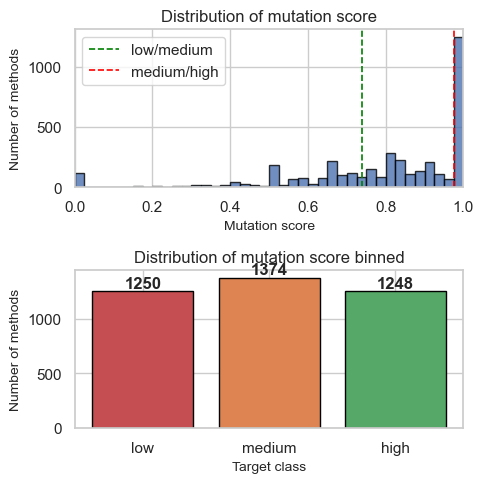


Mutation score statistics:
count    3872.000
mean        0.794
std         0.232
min         0.000
25%         0.673
50%         0.844
75%         1.000
max         1.000
Name: mutation_score, dtype: float64

Class balance (low/medium/high): {'low': np.int64(1250), 'medium': np.int64(1374), 'high': np.int64(1248)}
Imbalance ratio (max/min): 1.10


In [393]:
fig, axes = plt.subplots(2, 1, figsize=(5, 5))

# Continuous score histogram
axes[0].hist(df["mutation_score"], bins=40, edgecolor="black", alpha=0.8, color="#4C72B0")
axes[0].axvline(0.74, color="green",   linestyle="--", linewidth=1.2, label="low/medium")
axes[0].axvline(0.975, color="red", linestyle="--", linewidth=1.2, label="medium/high")
axes[0].set_xlabel("Mutation score")
axes[0].set_ylabel("Number of methods")
axes[0].set_title("Distribution of mutation score")
axes[0].legend()
axes[0].set_xlim(0.0,1)
# Binned class counts
bin_order = ["low", "medium", "high"]
counts = df[TARGET_COL].value_counts().reindex(bin_order)
colors = ["#C44E52", "#DD8452", "#55A868"]
axes[1].bar(counts.index, counts.values, color=colors, edgecolor="black")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")
axes[1].set_xlabel("Target class")
axes[1].set_ylabel("Number of methods")
axes[1].set_title("Distribution of mutation score binned")

plt.tight_layout()
plt.savefig(FIG_DIR / "target_distribution.pdf", bbox_inches="tight")
plt.show()

print(f"\nMutation score statistics:")
import pandas as pd

# This converts valid numbers to float and turns 'mutation_score' into NaN
df['mutation_score'] = pd.to_numeric(df['mutation_score'], errors='coerce')
print(df["mutation_score"].describe().round(3))
print(f"\nClass balance (low/medium/high): {dict(counts)}")
print(f"Imbalance ratio (max/min): {counts.max() / counts.min():.2f}")

**Observation.** The distribution is normal.

### 2.2 Project Distribution

The dataset combines two Defects4J projects. We check the relative contribution of each and whether the testability distribution differs between projects.

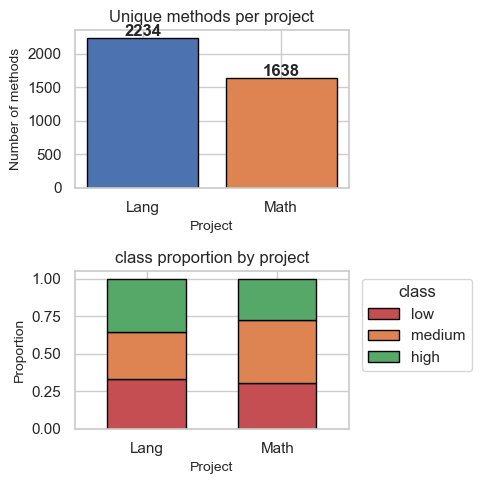


Mutation score by project:
          count   mean    std  min    25%    50%  75%  max
project                                                   
Lang     2234.0  0.802  0.223  0.0  0.677  0.839  1.0  1.0
Math     1638.0  0.784  0.242  0.0  0.667  0.850  1.0  1.0


In [394]:
fig, axes = plt.subplots(2, 1, figsize=(5, 5))

# Methods per project
proj_counts = df["project"].value_counts()
axes[0].bar(proj_counts.index, proj_counts.values, color=["#4C72B0", "#DD8452",], edgecolor="black")
for i, v in enumerate(proj_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")
axes[0].set_xlabel("Project")
axes[0].set_ylabel("Number of methods")
axes[0].set_title("Unique methods per project")

# Testability class distribution within each project
ct = pd.crosstab(df["project"], df[TARGET_COL], normalize="index")
ct = ct[bin_order]
ct.plot(kind="bar", stacked=True, ax=axes[1],
        color=["#C44E52", "#DD8452", "#55A868"], edgecolor="black", width=0.6)
axes[1].set_xlabel("Project")
axes[1].set_ylabel("Proportion")
axes[1].set_title("class proportion by project")
axes[1].legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "project_distribution.pdf", bbox_inches="tight")
plt.show()

print(f"\nMutation score by project:")
print(df.groupby("project")["mutation_score"].describe().round(3))

**Observation.** The two projects contribute roughly comparable amounts of data. If the class distributions differ between projects, the project itself carries predictive information — we will retain `project` as a feature via one-hot encoding.

### 2.3 Feature Distributions

Numerical features are inspected for skewness, outliers, and low variance columns.

In [395]:
# Identify numeric features
numeric_features = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features: {len(numeric_features)}")

# Summary statistics
print("\nFeature statistics (transposed):")
display_stats = df[numeric_features].describe().T[["mean", "std", "min", "50%", "max"]].round(3)
display_stats.columns = ["mean", "std", "min", "median", "max"]
print(display_stats)

Numeric features: 30

Feature statistics (transposed):
                         mean     std  min  median       max
loc                    10.571  14.174  2.0   7.000   167.000
num_params              1.660   1.244  0.0   1.000    14.000
num_local_vars          2.422   3.815  0.0   1.000    49.000
num_method_calls        8.029   9.706  1.0   5.000   180.000
num_arith_ops           3.434   9.649  0.0   1.000   195.000
num_rel_ops             2.824   4.316  0.0   2.000    52.000
num_logical_ops         0.571   1.901  0.0   0.000    25.000
num_literals            3.243   7.759  0.0   1.000   137.000
num_nodes              10.518  14.459  0.0   7.000   186.000
num_edges              11.060  17.169  0.0   7.000   215.000
cyclomatic_complexity   2.555   3.028  0.0   2.000    32.000
num_conditions          1.826   2.696  0.0   1.000    36.000
num_branches            2.632   3.420  0.0   2.000    41.000
num_joins               1.517   2.288  0.0   1.000    27.000
num_loops               1.255 

Plot histograms for a representative subset of features.

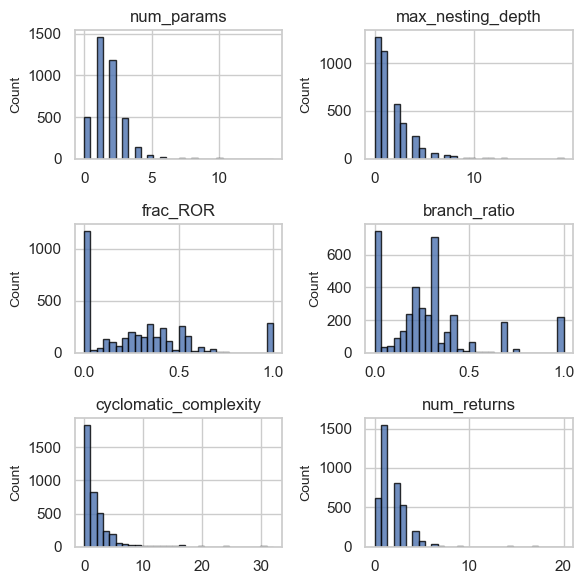

In [396]:
KEY_FEATURES = ["num_params",
    "max_nesting_depth", "frac_ROR", "branch_ratio", "cyclomatic_complexity", "num_returns"
]
KEY_FEATURES = [f for f in KEY_FEATURES if f in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(6, 6))
for ax, feat in zip(axes.flat, KEY_FEATURES):
    ax.hist(df[feat], bins=30, edgecolor="black", alpha=0.8, color="#4C72B0")
    ax.set_title(feat)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(FIG_DIR / "feature_histograms.pdf", bbox_inches="tight")
plt.show()

### 2.5 Feature Correlations

We compute Spearman correlations among numeric features. Spearman is preferred over Pearson because the features are right-skewed and we care about monotonic rather than linear relationships.

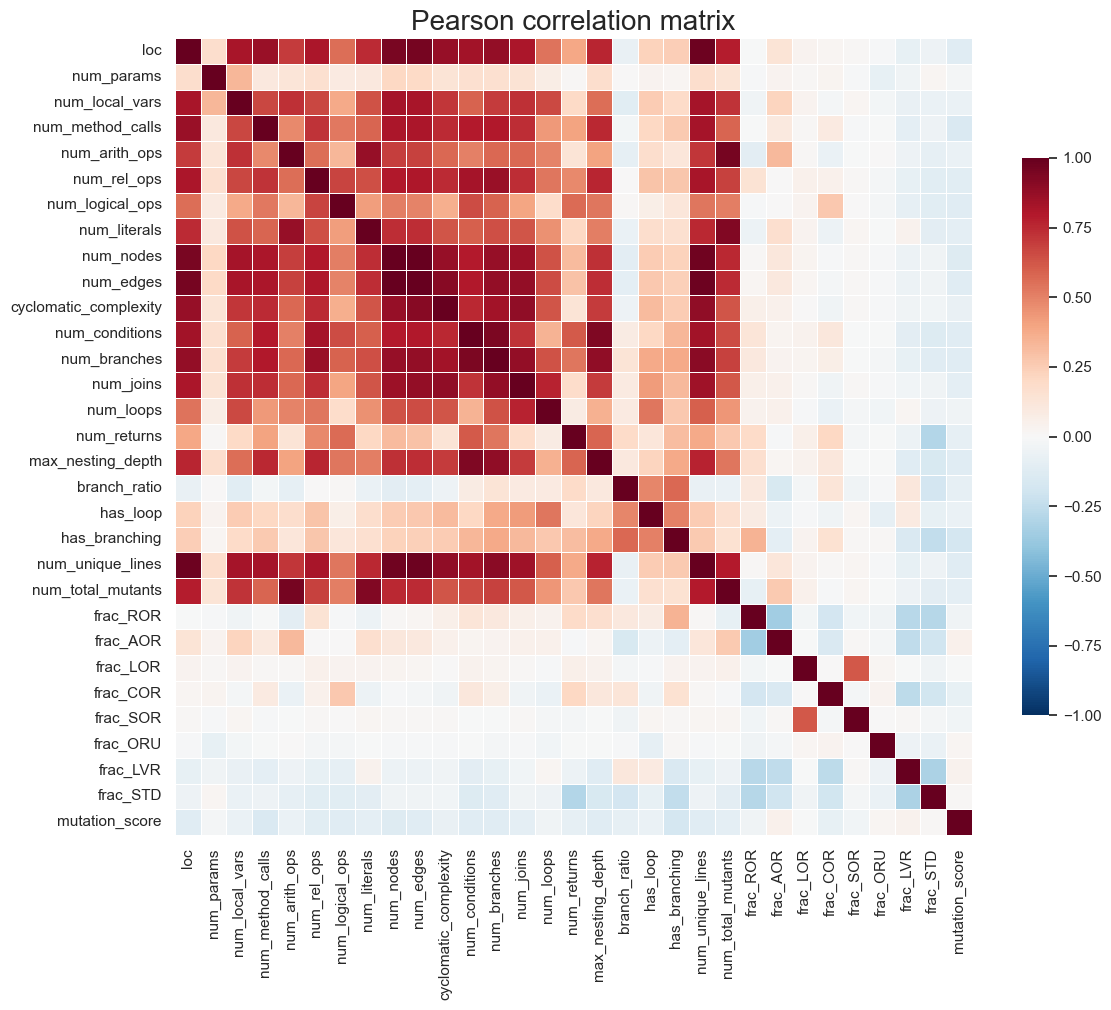

In [398]:
# Add mutation_score to see correlation with target for inspection
corr_cols = numeric_features + ["mutation_score"]
corr = df[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Pearson correlation matrix", fontsize = 20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.pdf", bbox_inches="tight")
plt.show()

Show top correlations with the continuous mutation score.

In [399]:
target_corr = corr["mutation_score"].drop("mutation_score").sort_values(ascending=False)
print("Pearson correlation with mutation_score (top and bottom 10):")
print("\nMost positive:")
print(target_corr.head(10).round(3))
print("\nMost negative:")
print(target_corr.tail(10).round(3))

Pearson correlation with mutation_score (top and bottom 10):

Most positive:
frac_AOR          0.050
frac_LVR          0.043
frac_ORU          0.016
frac_STD          0.014
frac_LOR         -0.004
num_params       -0.017
frac_SOR         -0.039
frac_ROR         -0.042
num_loops        -0.042
num_local_vars   -0.063
Name: mutation_score, dtype: float64

Most negative:
num_edges           -0.118
num_unique_lines    -0.118
num_logical_ops     -0.118
loc                 -0.119
num_branches        -0.119
num_conditions      -0.121
max_nesting_depth   -0.121
num_nodes           -0.125
num_method_calls    -0.149
has_branching       -0.174
Name: mutation_score, dtype: float64


**Observation.** No single feature shows a strong correlation with the target (the strongest is typically below |0.3|). This is consistent with the hypothesis that testability arises from a *combination* of structural factors, not a single dominating one — a setting where ensemble models often outperform linear models.

We also observe strong correlations *among features* (e.g., `cyclomatic_complexity` correlates with `num_branches` by construction, and `num_total_mutants` correlates with code size). These redundancies will inform feature selection later.

## 3. Preprocessing

Based on the EDA observations, the preprocessing pipeline performs the following steps:

. Drop identifier columns and outcome columns (only keep features and target)
. One-hot encode the `project` column
. Cap outliers using the IQR rule
. Standardize features using `StandardScaler`
. Save the preprocessed dataset for use in modeling

### 3.1 Selecting Features and Target

Identifier columns are kept aside for use as group labels during cross-validation.

In [401]:
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()
groups = df["class_fqn"].copy()  # for GroupKFold cross-validation later

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}, classes = {y.value_counts().to_dict()}")
print(f"Groups (class_fqn): {groups.nunique()} unique classes")

Feature matrix X: (3872, 31)
Target vector y: (3872,), classes = {'medium': 1374, 'low': 1250, 'high': 1248}
Groups (class_fqn): 118 unique classes


In [402]:
X

,project,loc,num_params,num_local_vars,num_method_calls,num_arith_ops,num_rel_ops,num_logical_ops,num_literals,num_nodes,...,num_unique_lines,num_total_mutants,frac_ROR,frac_AOR,frac_LOR,frac_COR,frac_SOR,frac_ORU,frac_LVR,frac_STD
0,Lang,10,2,1,7,2,4,1,4,10,...,8,24,0.416667,0.000000,0.000000,0.166667,0.000000,0.166667,0.166667,0.083333
1,Lang,16,3,3,11,4,6,1,8,17,...,13,45,0.400000,0.355556,0.000000,0.066667,0.000000,0.000000,0.177778,0.000000
2,Lang,17,2,2,10,2,7,2,9,18,...,15,52,0.346154,0.000000,0.038462,0.153846,0.000000,0.076923,0.269231,0.115385
3,Lang,21,2,3,12,11,13,3,25,23,...,18,141,0.255319,0.113475,0.056738,0.085106,0.014184,0.070922,0.340426,0.063830
4,Lang,44,1,17,10,16,7,4,20,43,...,42,131,0.160305,0.396947,0.000000,0.122137,0.000000,0.000000,0.198473,0.122137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3867,Math,4,1,0,3,0,0,0,0,2,...,2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3868,Math,4,1,0,3,0,0,0,1,2,...,2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3869,Math,34,3,12,22,16,7,0,6,59,...,33,66,0.318182,0.363636,0.000000,0.030303,0.000000,0.000000,0.181818,0.106061
3870,Math,4,0,0,4,0,1,0,0,3,...,3,2,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000


In [403]:
X

,project,loc,num_params,num_local_vars,num_method_calls,num_arith_ops,num_rel_ops,num_logical_ops,num_literals,num_nodes,...,num_unique_lines,num_total_mutants,frac_ROR,frac_AOR,frac_LOR,frac_COR,frac_SOR,frac_ORU,frac_LVR,frac_STD
0,Lang,10,2,1,7,2,4,1,4,10,...,8,24,0.416667,0.000000,0.000000,0.166667,0.000000,0.166667,0.166667,0.083333
1,Lang,16,3,3,11,4,6,1,8,17,...,13,45,0.400000,0.355556,0.000000,0.066667,0.000000,0.000000,0.177778,0.000000
2,Lang,17,2,2,10,2,7,2,9,18,...,15,52,0.346154,0.000000,0.038462,0.153846,0.000000,0.076923,0.269231,0.115385
3,Lang,21,2,3,12,11,13,3,25,23,...,18,141,0.255319,0.113475,0.056738,0.085106,0.014184,0.070922,0.340426,0.063830
4,Lang,44,1,17,10,16,7,4,20,43,...,42,131,0.160305,0.396947,0.000000,0.122137,0.000000,0.000000,0.198473,0.122137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3867,Math,4,1,0,3,0,0,0,0,2,...,2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3868,Math,4,1,0,3,0,0,0,1,2,...,2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3869,Math,34,3,12,22,16,7,0,6,59,...,33,66,0.318182,0.363636,0.000000,0.030303,0.000000,0.000000,0.181818,0.106061
3870,Math,4,0,0,4,0,1,0,0,3,...,3,2,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000


### 3.2 One-Hot Encoding

The `project` column is the only non-numeric feature. We encode it as binary indicator columns.

In [404]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns before encoding: {categorical_cols}")

if categorical_cols:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=False, dtype=int)

print(f"Shape after one-hot encoding: {X.shape}")
print(f"New columns: {[c for c in X.columns if any(c.startswith(orig + '_') for orig in categorical_cols)]}")

Categorical columns before encoding: ['project']
Shape after one-hot encoding: (3872, 32)
New columns: ['project_Lang', 'project_Math']


### 3.4 Outlier Capping (IQR)

Right-skewed features have extreme values that disproportionately influence many models. Rather than dropping rows (which loses samples) we cap each feature at the IQR-derived bounds.

For each feature, we compute Q1 (25th percentile) and Q3 (75th percentile), set the IQR = Q3 − Q1, and cap values outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. Binary one-hot indicator columns are excluded from capping.

In [405]:
def cap_outliers_iqr(df, columns, factor=1.5):
    """Cap values outside [Q1 - factor*IQR, Q3 + factor*IQR] per column.
    Returns the capped dataframe and a per-column count of capped values."""
    out = df.copy()
    capped_counts = {}
    for c in columns:
        q1 = out[c].quantile(0.25)
        q3 = out[c].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        n_capped = ((out[c] < lower) | (out[c] > upper)).sum()
        out[c] = out[c].clip(lower=lower, upper=upper)
        if n_capped > 0:
            capped_counts[c] = n_capped
    return out, capped_counts

# Don't cap binary one-hot indicators
binary_cols = [c for c in X.columns if X[c].nunique() <= 2]
cap_cols    = [c for c in X.columns if c not in binary_cols]

X_capped, capped_counts = cap_outliers_iqr(X, cap_cols, factor=1.5)

# Report features with the most outliers
caps_df = (pd.Series(capped_counts, name="n_capped")
           .sort_values(ascending=False)
           .to_frame()
           .assign(pct=lambda d: (d["n_capped"] / len(X) * 100).round(2)))
print(f"Outlier capping applied to {len(caps_df)} features")
print(f"\nTop 10 features by outlier count:")
print(caps_df.head(10))

X = X_capped

Outlier capping applied to 27 features

Top 10 features by outlier count:
                   n_capped    pct
frac_STD                448  11.57
branch_ratio            431  11.13
num_total_mutants       423  10.92
num_arith_ops           364   9.40
num_returns             362   9.35
num_unique_lines        361   9.32
loc                     361   9.32
frac_COR                341   8.81
num_literals            335   8.65
frac_LVR                327   8.45


In [406]:
X_capped.shape

(3872, 32)

Visualize the effect of capping on a few features.

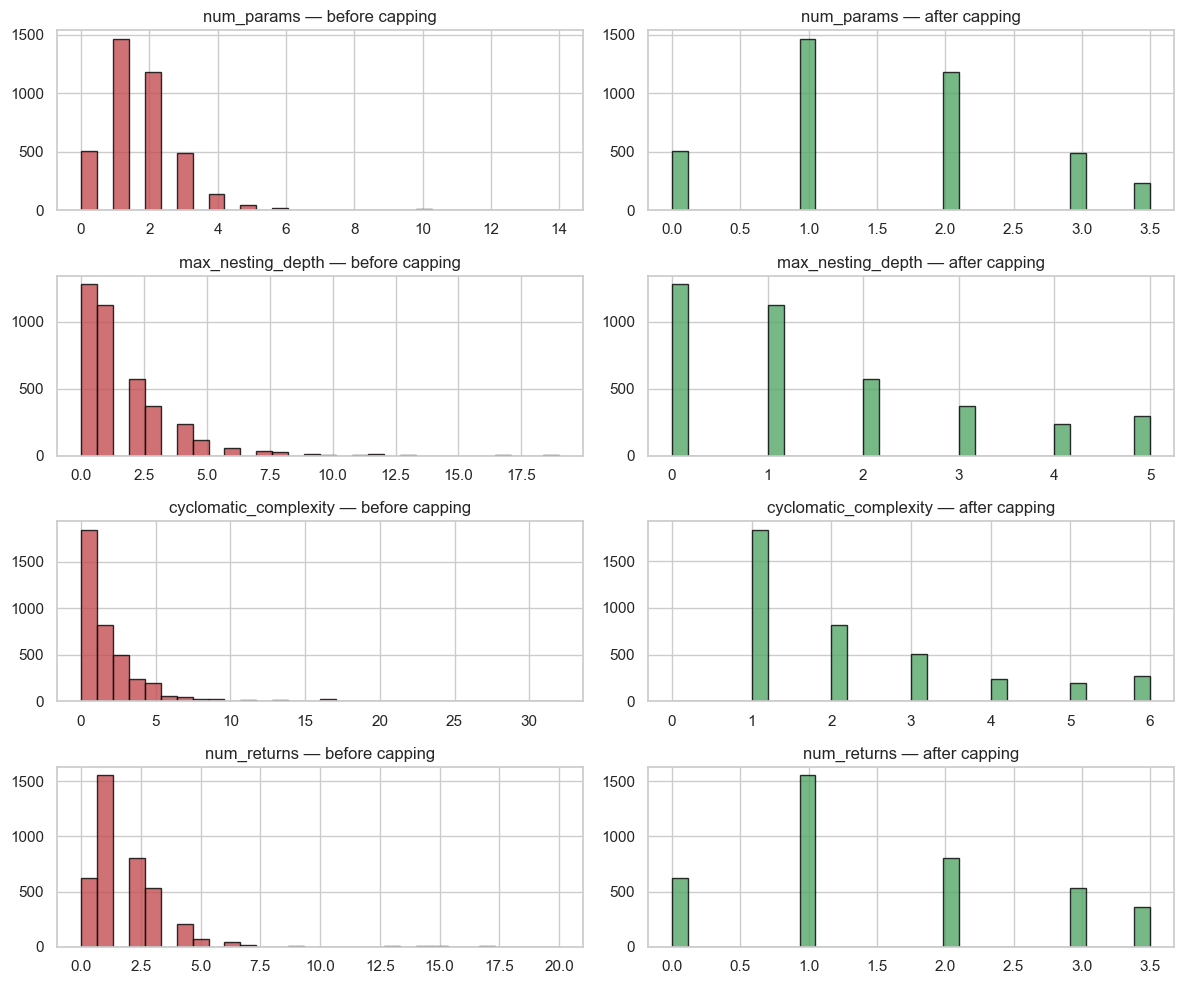

In [407]:
VIS_FEATURES = ["num_params", "max_nesting_depth", "cyclomatic_complexity", "num_returns"]
VIS_FEATURES = [f for f in VIS_FEATURES if f in df.columns and f in X.columns]

fig, axes = plt.subplots(len(VIS_FEATURES), 2, figsize=(12, 2.5 * len(VIS_FEATURES)))
for i, feat in enumerate(VIS_FEATURES):
    axes[i, 0].hist(df[feat], bins=30, edgecolor="black", alpha=0.8, color="#C44E52")
    axes[i, 0].set_title(f"{feat} — before capping")

    axes[i, 1].hist(X[feat], bins=30, edgecolor="black", alpha=0.8, color="#55A868")
    axes[i, 1].set_title(f"{feat} — after capping")

plt.tight_layout()
plt.savefig(FIG_DIR / "outlier_capping_effect.pdf", bbox_inches="tight")
plt.show()

**Observation.** Capping compresses the long right tails while preserving the central distribution. Methods that were extreme outliers (e.g., a single 500-line method) are pulled in to the upper IQR bound. This stabilizes downstream model training without dropping rows.

### 3.5 Encoding the Target

Convert the string class labels to ordinal integers for modeling. We map `low → 0, medium → 1, high → 2`, preserving the natural ordering of testability.

In [408]:
CLASS_TO_INT = {"low": 0, "medium": 1, "high": 2}
INT_TO_CLASS = {v: k for k, v in CLASS_TO_INT.items()}

y_encoded = y.map(CLASS_TO_INT)
print("Encoded class distribution:")
print(y_encoded.value_counts().sort_index().rename(index=INT_TO_CLASS))

Encoded class distribution:
mutation_score_bin
low       1250
medium    1374
high      1248
Name: count, dtype: int64


### 3.6 Standardization
We standardize each feature to zero mean and unit variance. Tree-based models are scale-invariant, but standardization does not harm them, so we keep one scaled version of the dataset for all models.

In [409]:
from sklearn.preprocessing import StandardScaler

# Save unscaled features for tree-based models
X_unscaled = X.copy()

# Globally scaled version for diagnostics
scaler_global = StandardScaler()
X_scaled = pd.DataFrame(scaler_global.fit_transform(X), columns=X.columns, index=X.index)

print(f"Unscaled features: mean range = [{X_unscaled.mean().min():.2f}, {X_unscaled.mean().max():.2f}]")
print(f"Scaled features:   mean range = [{X_scaled.mean().min():.2f}, {X_scaled.mean().max():.2f}]")
print(f"Scaled features:   std  range = [{X_scaled.std().min():.2f}, {X_scaled.std().max():.2f}]")

Unscaled features: mean range = [0.00, 16.26]
Scaled features:   mean range = [-0.00, 0.00]
Scaled features:   std  range = [0.00, 1.00]


### 3.7 Saving the Preprocessed Dataset

Save the cleaned dataset to disk for the modeling notebook to consume.

In [410]:
OUT_DIR = Path("preprocessed")
OUT_DIR.mkdir(exist_ok=True)

X_unscaled.to_csv(OUT_DIR / "X_unscaled.csv", index=False)
X_scaled.to_csv(OUT_DIR / "X_scaled.csv", index=False)
y_encoded.to_csv(OUT_DIR / "y.csv", index=False, header=["mutation_score_bin"])
groups.to_csv(OUT_DIR / "groups.csv", index=False, header=["class_fqn"])

# Also save a metadata file with column info
import json
meta = {
    "n_rows": len(X_unscaled),
    "n_features": X_unscaled.shape[1],
    "feature_names": X_unscaled.columns.tolist(),
    "class_to_int": CLASS_TO_INT,
    "class_counts": y.value_counts().to_dict(),
    "project_counts": df["project"].value_counts().to_dict(),
    "removed_low_variance": low_var_cols,
    "outlier_capping": {"factor": 1.5, "method": "IQR"},
}
with open(OUT_DIR / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved preprocessed dataset to {OUT_DIR}/")
print(f"  X_unscaled.csv: {X_unscaled.shape}")
print(f"  X_scaled.csv:   {X_scaled.shape}")
print(f"  y.csv:          {y_encoded.shape}")
print(f"  groups.csv:     {groups.shape}")
print(f"  metadata.json")

Saved preprocessed dataset to preprocessed/
  X_unscaled.csv: (3872, 32)
  X_scaled.csv:   (3872, 32)
  y.csv:          (3872,)
  groups.csv:     (3872,)
  metadata.json


PCA

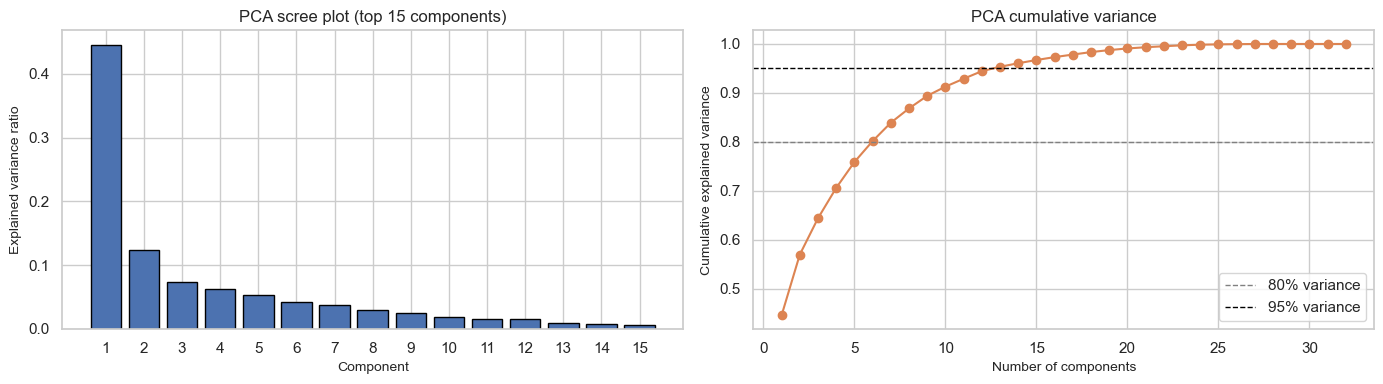

Components needed for 80% variance: 6
Components needed for 95% variance: 13
Variance explained by first 2 components: 0.570


In [411]:
from sklearn.decomposition import PCA

pca = PCA(random_state=SEED)
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scree plot
n_show = min(15, len(explained))
axes[0].bar(range(1, n_show + 1), explained[:n_show], color="#4C72B0", edgecolor="black")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("PCA scree plot (top 15 components)")
axes[0].set_xticks(range(1, n_show + 1))

# Cumulative variance
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o", color="#DD8452")
axes[1].axhline(0.80, color="grey", linestyle="--", linewidth=1, label="80% variance")
axes[1].axhline(0.95, color="black", linestyle="--", linewidth=1, label="95% variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("PCA cumulative variance")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "pca_variance.pdf", bbox_inches="tight")
plt.show()

# How many components for 80% / 95% variance?
n_80 = int(np.argmax(cumulative >= 0.80) + 1)
n_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed for 80% variance: {n_80}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Variance explained by first 2 components: {cumulative[1]:.3f}")

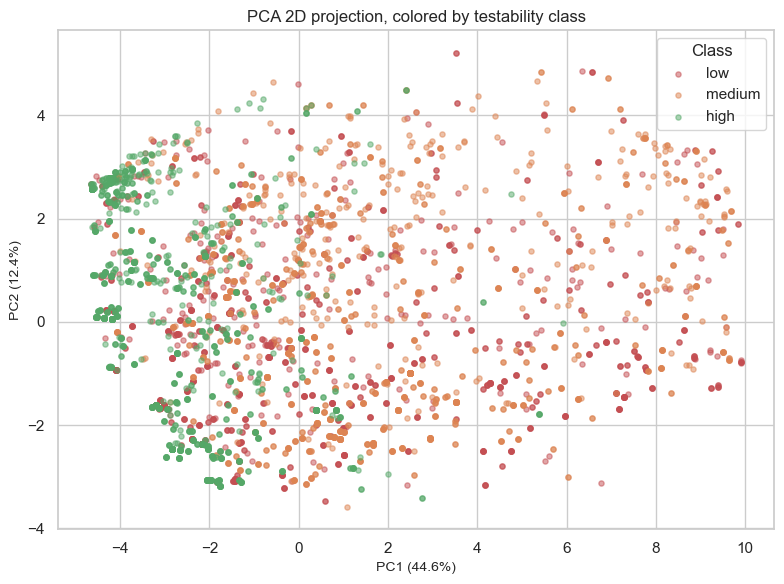

In [412]:
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2 = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
class_colors = {"low": "#C44E52", "medium": "#DD8452", "high": "#55A868"}
for cls in bin_order:
    mask = (y == cls).values
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               s=14, alpha=0.5, color=class_colors[cls], label=cls)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA 2D projection, colored by testability class")
ax.legend(title="Class")
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_2d_projection.pdf", bbox_inches="tight")
plt.show()





Choosing the number of clusters — elbow and silhouette
We sweep over candidate values of K and use two diagnostics:

Elbow (inertia, i.e., within-cluster sum of squares): we look for the point where adding clusters stops reducing inertia meaningfully.
Silhouette score: higher is better, measures how well-separated the clusters are. Range is [-1, 1].

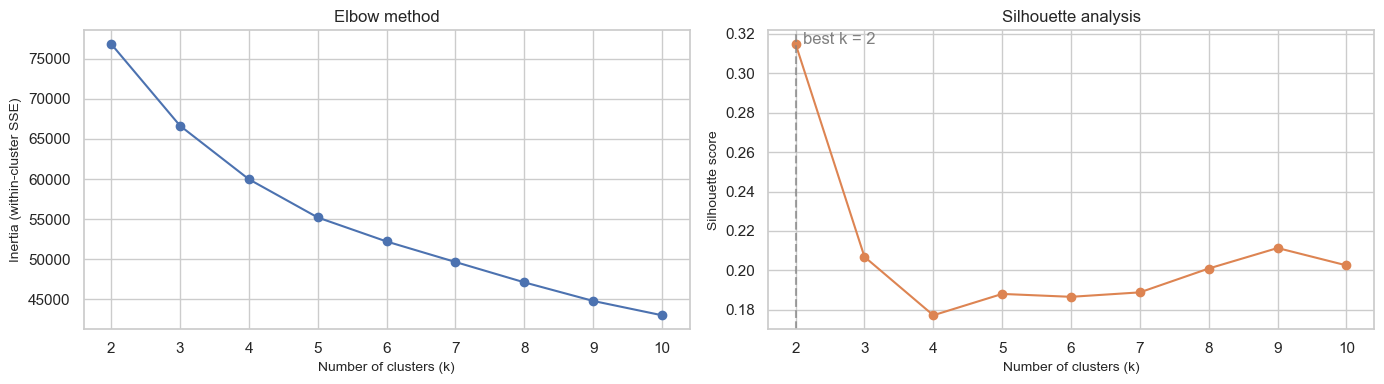


Silhouette scores by k:
  k=2: silhouette = 0.3148 *
  k=3: silhouette = 0.2069
  k=4: silhouette = 0.1773
  k=5: silhouette = 0.1881
  k=6: silhouette = 0.1866
  k=7: silhouette = 0.1889
  k=8: silhouette = 0.2010
  k=9: silhouette = 0.2114
  k=10: silhouette = 0.2026

Best k by silhouette: 2
k=3 silhouette (for comparison with our 3-class target): 0.2069


In [413]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = list(range(2, 11))
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_RANGE, inertias, marker="o", color="#4C72B0")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow method")
axes[0].set_xticks(K_RANGE)

axes[1].plot(K_RANGE, silhouettes, marker="o", color="#DD8452")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette analysis")
axes[1].set_xticks(K_RANGE)
best_k = K_RANGE[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color="grey", linestyle="--", alpha=0.7)
axes[1].text(best_k + 0.1, max(silhouettes), f"best k = {best_k}", color="grey")

plt.tight_layout()
plt.savefig(FIG_DIR / "kmeans_selection.pdf", bbox_inches="tight")
plt.show()

print(f"\nSilhouette scores by k:")
for k, s in zip(K_RANGE, silhouettes):
    marker = " *" if k == best_k else ""
    print(f"  k={k}: silhouette = {s:.4f}{marker}")
print(f"\nBest k by silhouette: {best_k}")
print(f"k=3 silhouette (for comparison with our 3-class target): {silhouettes[K_RANGE.index(3)]:.4f}")

Observation. The elbow plot shows a gradual decrease in inertia rather than a sharp knee — typical for real-world data where clusters are not perfectly separated. The silhouette score indicates the most cohesive number of clusters; we will also run K-Means at k=3 to match the testability bins for direct comparison.

#### Comparing K-Means clusters to testability classes

We run K-Means at k=3 and measure how well the resulting clusters match the true testability classes using three metrics:

- **Homogeneity**: are clusters pure (each cluster contains methods from mostly one class)?
- **Completeness**: are classes intact (methods of a given class end up in the same cluster)?
- **Adjusted Rand Index (ARI)**: overall agreement, corrected for chance. 0 = random, 1 = identical.

In [414]:
from sklearn.metrics import (
    homogeneity_score, completeness_score, adjusted_rand_score, v_measure_score,
)

km3 = KMeans(n_clusters=3, n_init=10, random_state=SEED)
km3_labels = km3.fit_predict(X_scaled)

# Compare cluster assignments to the true labels
y_int = y_encoded.values
km3_homog = homogeneity_score(y_int, km3_labels)
km3_compl = completeness_score(y_int, km3_labels)
km3_vmeas = v_measure_score(y_int, km3_labels)
km3_ari   = adjusted_rand_score(y_int, km3_labels)

print(f"K-Means (k=3) vs testability class:")
print(f"  Homogeneity:          {km3_homog:.4f}")
print(f"  Completeness:         {km3_compl:.4f}")
print(f"  V-measure (harmonic): {km3_vmeas:.4f}")
print(f"  Adjusted Rand Index:  {km3_ari:.4f}")

# Cross-tab: which cluster contains how many of each class?
ct = pd.crosstab(pd.Series(km3_labels, name="K-Means cluster"),
                 pd.Series(y.values,   name="True class"))
print(f"\nCluster vs class cross-tabulation:")
print(ct.to_string())

K-Means (k=3) vs testability class:
  Homogeneity:          0.1234
  Completeness:         0.1397
  V-measure (harmonic): 0.1311
  Adjusted Rand Index:  0.0667

Cluster vs class cross-tabulation:
True class       high  low  medium
K-Means cluster                   
0                 520  140      84
1                  12  366     503
2                 716  744     787


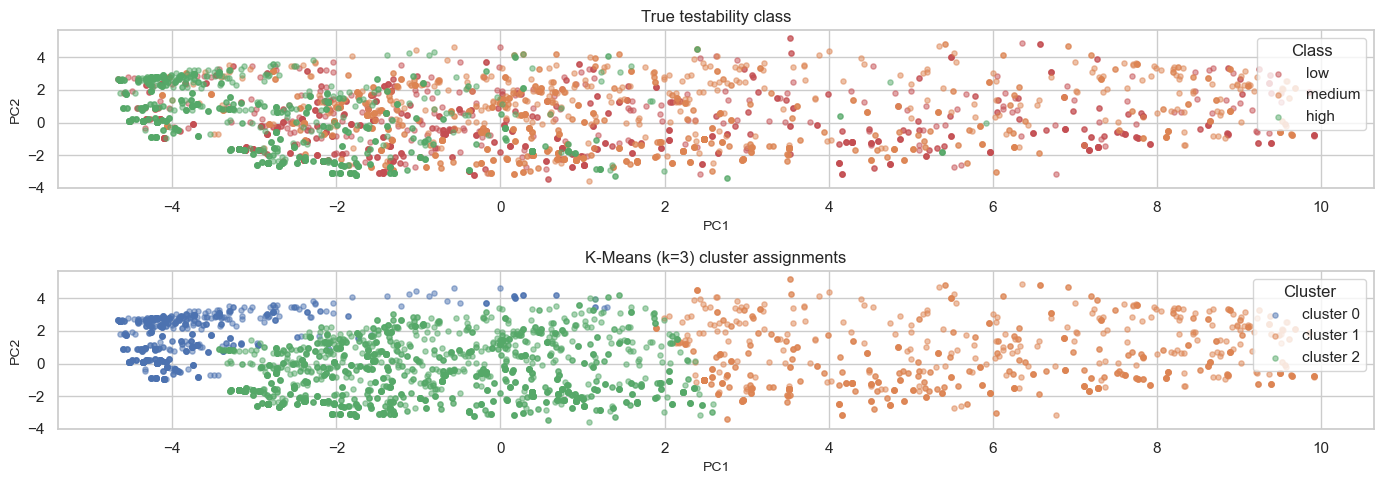

In [415]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# True classes
for cls in bin_order:
    mask = (y == cls).values
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    s=14, alpha=0.5, color=class_colors[cls], label=cls)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("True testability class")
axes[0].legend(title="Class")

# K-Means clusters
cluster_colors = ["#4C72B0", "#DD8452", "#55A868"]
for c in range(3):
    mask = (km3_labels == c)
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    s=14, alpha=0.5, color=cluster_colors[c],
                    label=f"cluster {c}")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("K-Means (k=3) cluster assignments")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.savefig(FIG_DIR / "kmeans_vs_class.png", bbox_inches="tight")
plt.show()

In [417]:
agg3 = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg3_labels = agg3.fit_predict(X_scaled)

agg3_homog = homogeneity_score(y_int, agg3_labels)
agg3_compl = completeness_score(y_int, agg3_labels)
agg3_vmeas = v_measure_score(y_int, agg3_labels)
agg3_ari   = adjusted_rand_score(y_int, agg3_labels)

print(f"Hierarchical (Ward, k=3) vs testability class:")
print(f"  Homogeneity:          {agg3_homog:.4f}")
print(f"  Completeness:         {agg3_compl:.4f}")
print(f"  V-measure (harmonic): {agg3_vmeas:.4f}")
print(f"  Adjusted Rand Index:  {agg3_ari:.4f}")

ct_agg = pd.crosstab(pd.Series(agg3_labels, name="Hierarchical cluster"),
                     pd.Series(y.values,    name="True class"))
print(f"\nCluster vs class cross-tabulation:")
print(ct_agg.to_string())

Hierarchical (Ward, k=3) vs testability class:
  Homogeneity:          0.0997
  Completeness:         0.1282
  V-measure (harmonic): 0.1121
  Adjusted Rand Index:  0.0507

Cluster vs class cross-tabulation:
True class            high  low  medium
Hierarchical cluster                   
0                      738  853    1025
1                       11  283     271
2                      499  114      78


In [419]:
PREP_DIR = Path("preprocessed")

X_unscaled = pd.read_csv(PREP_DIR / "X_unscaled.csv")
X_scaled   = pd.read_csv(PREP_DIR / "X_scaled.csv")
y          = pd.read_csv(PREP_DIR / "y.csv").squeeze()
groups     = pd.read_csv(PREP_DIR / "groups.csv").squeeze()

with open(PREP_DIR / "metadata.json") as f:
    meta = json.load(f)

CLASS_TO_INT = meta["class_to_int"]
INT_TO_CLASS = {v: k for k, v in CLASS_TO_INT.items()}
CLASS_NAMES  = [INT_TO_CLASS[i] for i in sorted(INT_TO_CLASS.keys())]

print(f"X_unscaled: {X_unscaled.shape}")
print(f"X_scaled:   {X_scaled.shape}")
print(f"y:          {y.shape}, class counts = {dict(y.value_counts().sort_index().rename(index=INT_TO_CLASS))}")
print(f"groups:     {groups.shape}, {groups.nunique()} unique class_fqn values")

X_unscaled: (3872, 32)
X_scaled:   (3872, 32)
y:          (3872,), class counts = {'low': np.int64(1250), 'medium': np.int64(1374), 'high': np.int64(1248)}
groups:     (3872,), 118 unique class_fqn values


Model Training

In [420]:
MODELS = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=SEED,
    ),
    "KNN (k=15)": KNeighborsClassifier(
        n_neighbors=15, weights="distance",
    ),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", n_jobs=-1, random_state=SEED,
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, learning_rate=0.5, random_state=SEED,
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500,
        early_stopping=True, random_state=SEED,
    ),
}

# Tree-based models receive unscaled features; the rest receive scaled.
USE_SCALED = {"Decision Tree": False, "KNN (k=15)": True, "Naive Bayes": True,
              "Random Forest": False, "AdaBoost": False, "MLP": True}

print(f"{len(MODELS)} models defined:")
for name in MODELS:
    print(f"  - {name}  (scaled inputs: {USE_SCALED[name]})")

6 models defined:
  - Decision Tree  (scaled inputs: False)
  - KNN (k=15)  (scaled inputs: True)
  - Naive Bayes  (scaled inputs: True)
  - Random Forest  (scaled inputs: False)
  - AdaBoost  (scaled inputs: False)
  - MLP  (scaled inputs: True)


In [421]:
OP_COLS  = [c for c in X_unscaled.columns if c.startswith("frac_")]
LOC_COLS = ["loc"]

BASELINES = {
    "Baseline: Majority class": (
        DummyClassifier(strategy="most_frequent"),
        X_unscaled.columns.tolist(),
        False,
    ),
    "Baseline: LOC-only tree": (
        DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=SEED),
        LOC_COLS,
        False,
    ),
    "Baseline: Operator-only tree": (
        DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=SEED),
        OP_COLS,
        False,
    ),
}

print(f"{len(BASELINES)} baselines defined:")
for name, (_, cols, _) in BASELINES.items():
    print(f"  - {name}  ({len(cols)} features)")

3 baselines defined:
  - Baseline: Majority class  (32 features)
  - Baseline: LOC-only tree  (1 features)
  - Baseline: Operator-only tree  (8 features)


In [422]:
N_SPLITS = 5
strat_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
group_cv = GroupKFold(n_splits=N_SPLITS)

print(f"Stratified 5-fold CV: {N_SPLITS} folds")
print(f"GroupKFold by class_fqn: {N_SPLITS} folds")
print(f"  unique class_fqn groups = {groups.nunique()}")

Stratified 5-fold CV: 5 folds
GroupKFold by class_fqn: 5 folds
  unique class_fqn groups = 118


In [423]:
def evaluate_model(model, X, y, cv, groups=None, use_scaled=True):
    """Run cross-validation and return per-fold metrics + averaged predictions.
    Wraps the model in a Pipeline so scaling happens INSIDE the train fold only,
    preventing leakage.
    """
    if use_scaled:
        pipeline = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    else:
        pipeline = Pipeline([("clf", model)])

    accs, f1s, aucs = [], [], []
    splits = cv.split(X, y, groups) if groups is not None else cv.split(X, y)

    y_pred_all = np.zeros(len(y), dtype=int)
    y_proba_all = np.zeros((len(y), len(np.unique(y))))

    for train_idx, test_idx in splits:
        Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
        ytr, yte = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(Xtr, ytr)
        pred = pipeline.predict(Xte)
        y_pred_all[test_idx] = pred

        try:
            proba = pipeline.predict_proba(Xte)
            y_proba_all[test_idx] = proba
            auc = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
        except Exception:
            auc = np.nan

        accs.append(accuracy_score(yte, pred))
        f1s.append(f1_score(yte, pred, average="macro"))
        aucs.append(auc)

    return {
        "accuracy_mean": np.mean(accs), "accuracy_std": np.std(accs),
        "f1_mean": np.mean(f1s),         "f1_std": np.std(f1s),
        "auc_mean": np.nanmean(aucs),    "auc_std": np.nanstd(aucs),
        "y_pred": y_pred_all,
        "y_proba": y_proba_all,
    }

In [424]:
def select_X(use_scaled):
    return X_scaled if use_scaled else X_unscaled

all_results = []
all_predictions = {}  # (model_name, cv_name) -> y_pred for confusion matrices

# Baselines
for name, (model, cols, scaled) in BASELINES.items():
    X_use = select_X(scaled)[cols]
    for cv_name, cv_obj, grp in [("Stratified 5-fold", strat_cv, None),
                                  ("GroupKFold by class", group_cv, groups)]:
        res = evaluate_model(model, X_use, y, cv_obj, grp, scaled)
        all_results.append({
            "model": name, "cv": cv_name,
            "accuracy": f"{res['accuracy_mean']:.3f} ± {res['accuracy_std']:.3f}",
            "macro_f1": f"{res['f1_mean']:.3f} ± {res['f1_std']:.3f}",
            "macro_auc": f"{res['auc_mean']:.3f} ± {res['auc_std']:.3f}",
            "_accuracy_mean": res["accuracy_mean"], "_f1_mean": res["f1_mean"],
            "_auc_mean": res["auc_mean"],
        })
        all_predictions[(name, cv_name)] = res["y_pred"]
        print(f"  {name:35s} | {cv_name:20s} | acc={res['accuracy_mean']:.3f} f1={res['f1_mean']:.3f}")

# Main models
print()
for name, model in MODELS.items():
    use_scaled = USE_SCALED[name]
    X_use = select_X(use_scaled)
    for cv_name, cv_obj, grp in [("Stratified 5-fold", strat_cv, None),
                                  ("GroupKFold by class", group_cv, groups)]:
        res = evaluate_model(model, X_use, y, cv_obj, grp, use_scaled)
        all_results.append({
            "model": name, "cv": cv_name,
            "accuracy": f"{res['accuracy_mean']:.3f} ± {res['accuracy_std']:.3f}",
            "macro_f1": f"{res['f1_mean']:.3f} ± {res['f1_std']:.3f}",
            "macro_auc": f"{res['auc_mean']:.3f} ± {res['auc_std']:.3f}",
            "_accuracy_mean": res["accuracy_mean"], "_f1_mean": res["f1_mean"],
            "_auc_mean": res["auc_mean"],
        })
        all_predictions[(name, cv_name)] = res["y_pred"]
        print(f"  {name:35s} | {cv_name:20s} | acc={res['accuracy_mean']:.3f} f1={res['f1_mean']:.3f}")

results_df = pd.DataFrame(all_results)
print(f"\n{len(results_df)} model-CV combinations evaluated.")

  Baseline: Majority class            | Stratified 5-fold    | acc=0.355 f1=0.175
  Baseline: Majority class            | GroupKFold by class  | acc=0.355 f1=0.174
  Baseline: LOC-only tree             | Stratified 5-fold    | acc=0.558 f1=0.534
  Baseline: LOC-only tree             | GroupKFold by class  | acc=0.524 f1=0.498
  Baseline: Operator-only tree        | Stratified 5-fold    | acc=0.632 f1=0.623
  Baseline: Operator-only tree        | GroupKFold by class  | acc=0.571 f1=0.557

  Decision Tree                       | Stratified 5-fold    | acc=0.808 f1=0.807
  Decision Tree                       | GroupKFold by class  | acc=0.643 f1=0.636
  KNN (k=15)                          | Stratified 5-fold    | acc=0.878 f1=0.878
  KNN (k=15)                          | GroupKFold by class  | acc=0.720 f1=0.713
  Naive Bayes                         | Stratified 5-fold    | acc=0.559 f1=0.502
  Naive Bayes                         | GroupKFold by class  | acc=0.561 f1=0.516
  Random Forest

In [425]:
# Pivot into a readable table: one row per model, columns for each CV strategy
def pretty_table(metric):
    pivot = results_df.pivot(index="model", columns="cv", values=metric)
    # Order rows: baselines first, then main models
    order = list(BASELINES.keys()) + list(MODELS.keys())
    pivot = pivot.reindex(order)
    return pivot

print("=" * 70)
print("ACCURACY (mean ± std across folds)")
print("=" * 70)
print(pretty_table("accuracy").to_string())
print()
print("=" * 70)
print("MACRO-F1 (mean ± std across folds)")
print("=" * 70)
print(pretty_table("macro_f1").to_string())
print()
print("=" * 70)
print("MACRO-AUC (one-vs-rest, mean ± std across folds)")
print("=" * 70)
print(pretty_table("macro_auc").to_string())


ACCURACY (mean ± std across folds)
cv                           GroupKFold by class Stratified 5-fold
model                                                             
Baseline: Majority class           0.355 ± 0.036     0.355 ± 0.000
Baseline: LOC-only tree            0.524 ± 0.046     0.558 ± 0.013
Baseline: Operator-only tree       0.571 ± 0.032     0.632 ± 0.006
Decision Tree                      0.643 ± 0.058     0.808 ± 0.022
KNN (k=15)                         0.720 ± 0.092     0.878 ± 0.012
Naive Bayes                        0.561 ± 0.038     0.559 ± 0.016
Random Forest                      0.751 ± 0.090     0.881 ± 0.009
AdaBoost                           0.588 ± 0.037     0.599 ± 0.011
MLP                                0.641 ± 0.054     0.789 ± 0.035

MACRO-F1 (mean ± std across folds)
cv                           GroupKFold by class Stratified 5-fold
model                                                             
Baseline: Majority class           0.174 ± 0.013     0.175

In [426]:
pretty_table("accuracy").to_csv(RESULTS_DIR / "accuracy_table.csv")
pretty_table("macro_f1").to_csv(RESULTS_DIR / "f1_table.csv")
pretty_table("macro_auc").to_csv(RESULTS_DIR / "auc_table.csv")
results_df.to_csv(RESULTS_DIR / "results_long.csv", index=False)
print(f"Saved 4 result tables to {RESULTS_DIR}/")

Saved 4 result tables to results/


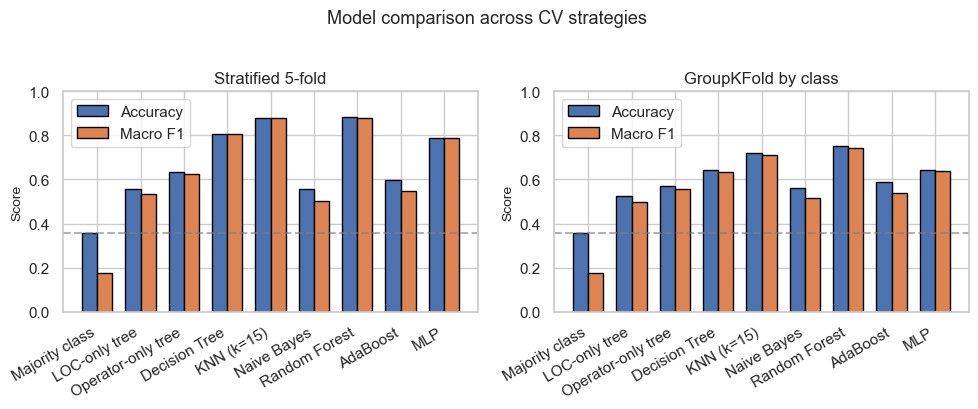

In [427]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

order = list(BASELINES.keys()) + list(MODELS.keys())

for ax, cv_name in zip(axes, ["Stratified 5-fold", "GroupKFold by class"]):
    sub = results_df[results_df["cv"] == cv_name].set_index("model").reindex(order)
    x_pos = np.arange(len(sub))
    width = 0.35
    ax.bar(x_pos - width/2, sub["_accuracy_mean"], width, label="Accuracy",
           color="#4C72B0", edgecolor="black")
    ax.bar(x_pos + width/2, sub["_f1_mean"], width, label="Macro F1",
           color="#DD8452", edgecolor="black")
    ax.set_xticks(x_pos)
    clean_labels = [label.replace("Baseline: ", "") for label in sub.index]
    ax.set_xticklabels(clean_labels, rotation=30, ha="right")
    ax.set_ylabel("Score")
    ax.set_title(f"{cv_name}")
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left")
    ax.axhline(y=sub.loc["Baseline: Majority class", "_accuracy_mean"],
               color="grey", linestyle="--", alpha=0.6, label="_nolegend_")

plt.suptitle("Model comparison across CV strategies", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison.pdf", bbox_inches="tight")
plt.show()

Top 4 models under GroupKFold (by macro-F1): ['Random Forest', 'KNN (k=15)', 'MLP', 'Decision Tree']


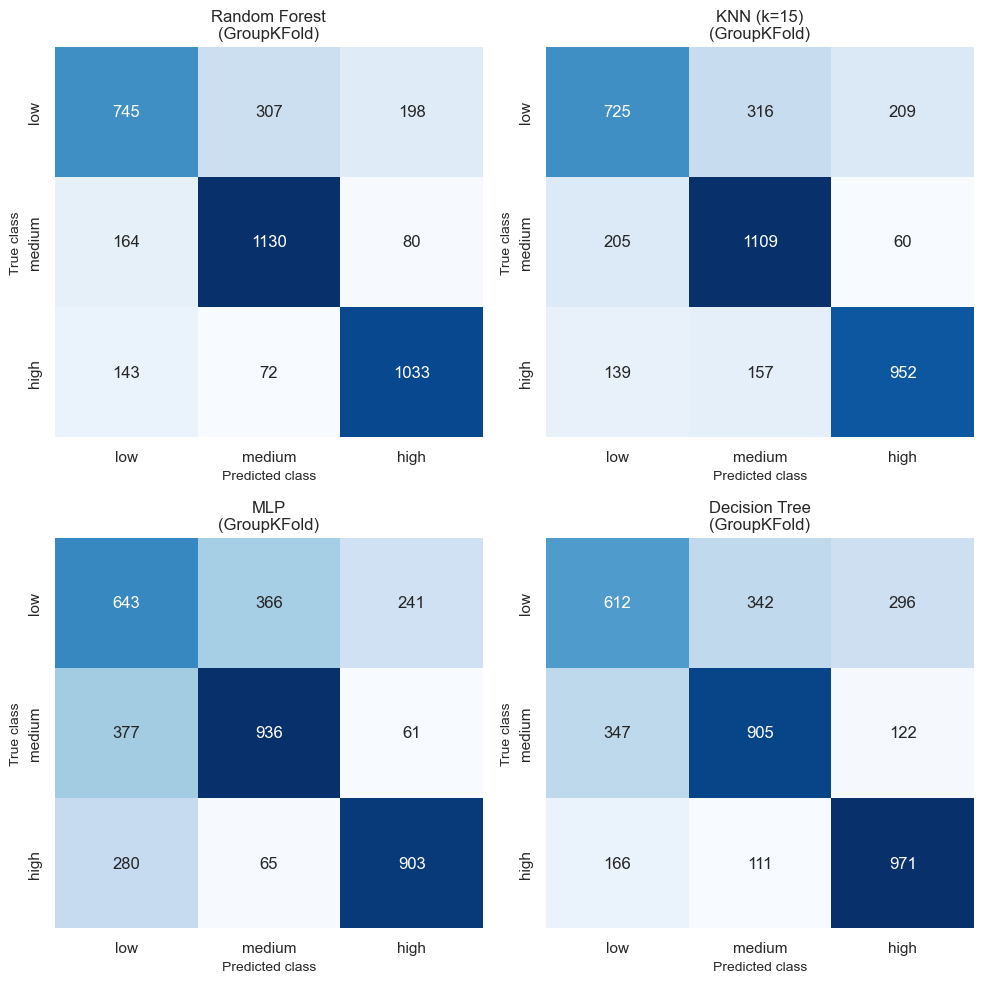


Classification report — Random Forest (GroupKFold):
              precision    recall  f1-score   support

         low      0.708     0.596     0.647      1250
      medium      0.749     0.822     0.784      1374
        high      0.788     0.828     0.807      1248

    accuracy                          0.751      3872
   macro avg      0.748     0.749     0.746      3872
weighted avg      0.748     0.751     0.747      3872



In [428]:
def plot_confmat(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(CLASS_TO_INT.values()))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                cbar=False)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)

# Identify the top 3 main (non-baseline) models under GroupKFold by macro-F1
groupkfold_results = results_df[
    (results_df["cv"] == "GroupKFold by class") &
    (~results_df["model"].str.startswith("Baseline:"))
].sort_values("_f1_mean", ascending=False)

top3 = groupkfold_results.head(4)["model"].tolist()
print(f"Top 4 models under GroupKFold (by macro-F1): {top3}")

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, name in zip(axes.flat, top3):
    y_pred = all_predictions[(name, "GroupKFold by class")]
    plot_confmat(ax, y, y_pred, f"{name}\n(GroupKFold)")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices_top3.pdf", bbox_inches="tight")
plt.show()

# Also print classification reports for the very best model
best = top3[0]
print(f"\nClassification report — {best} (GroupKFold):")
print(classification_report(y, all_predictions[(best, "GroupKFold by class")],
                            target_names=CLASS_NAMES, digits=3))

In [429]:
from sklearn.decomposition import PCA

PCA_VARIANCE = 0.80  # retain 80% of variance

def evaluate_with_pca(model, X, y, cv, groups, use_scaled, use_pca, pca_var=PCA_VARIANCE):
    """Run CV with optional PCA. PCA always implies scaling (PCA needs scaled
    input). Scaler and PCA are fit on the train fold only via Pipeline.
    """
    steps = []
    if use_scaled or use_pca:
        steps.append(("scaler", StandardScaler()))
    if use_pca:
        steps.append(("pca", PCA(n_components=pca_var, random_state=SEED)))
    steps.append(("clf", model))
    pipeline = Pipeline(steps)

    accs, f1s, aucs = [], [], []
    y_pred_all = np.zeros(len(y), dtype=int)

    for train_idx, test_idx in cv.split(X, y, groups):
        Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
        ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
        pipeline.fit(Xtr, ytr)
        pred = pipeline.predict(Xte)
        y_pred_all[test_idx] = pred
        try:
            proba = pipeline.predict_proba(Xte)
            auc = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
        except Exception:
            auc = np.nan
        accs.append(accuracy_score(yte, pred))
        f1s.append(f1_score(yte, pred, average="macro"))
        aucs.append(auc)

    return {
        "accuracy_mean": np.mean(accs), "accuracy_std": np.std(accs),
        "f1_mean": np.mean(f1s),         "f1_std": np.std(f1s),
        "auc_mean": np.nanmean(aucs),    "auc_std": np.nanstd(aucs),
        "y_pred": y_pred_all,
    }

# First, report how many components PCA chooses on the full data
_pca_check = PCA(n_components=PCA_VARIANCE, random_state=SEED)
_pca_check.fit(StandardScaler().fit_transform(X_scaled))
n_components_used = _pca_check.n_components_
print(f"PCA with {PCA_VARIANCE*100:.0f}% variance threshold "
      f"selects {n_components_used} components (out of {X_scaled.shape[1]})")

PCA with 80% variance threshold selects 6 components (out of 32)


In [430]:
# Run all main models with and without PCA, using GroupKFold by class
pca_rows = []
for name, model in MODELS.items():
    fresh_no  = type(model)(**model.get_params())
    fresh_yes = type(model)(**model.get_params())

    res_no  = evaluate_with_pca(fresh_no,  X_scaled, y, group_cv, groups,
                                 use_scaled=USE_SCALED[name], use_pca=False)
    res_yes = evaluate_with_pca(fresh_yes, X_scaled, y, group_cv, groups,
                                 use_scaled=USE_SCALED[name], use_pca=True)

    pca_rows.append({
        "model": name,
        "acc_no_pca":  f"{res_no['accuracy_mean']:.3f} ± {res_no['accuracy_std']:.3f}",
        "f1_no_pca":   f"{res_no['f1_mean']:.3f} ± {res_no['f1_std']:.3f}",
        "acc_with_pca": f"{res_yes['accuracy_mean']:.3f} ± {res_yes['accuracy_std']:.3f}",
        "f1_with_pca":  f"{res_yes['f1_mean']:.3f} ± {res_yes['f1_std']:.3f}",
        "_acc_no":  res_no["accuracy_mean"],
        "_f1_no":   res_no["f1_mean"],
        "_acc_yes": res_yes["accuracy_mean"],
        "_f1_yes":  res_yes["f1_mean"],
        "_delta_f1": res_yes["f1_mean"] - res_no["f1_mean"],
    })
    delta = res_yes["f1_mean"] - res_no["f1_mean"]
    arrow = "↑" if delta > 0.005 else ("↓" if delta < -0.005 else "→")
    print(f"  {name:25s}  no-PCA F1={res_no['f1_mean']:.3f}  "
          f"with-PCA F1={res_yes['f1_mean']:.3f}  {arrow} Δ={delta:+.3f}")

pca_df = pd.DataFrame(pca_rows)
print(f"\n{len(pca_df)} model comparisons completed.")

  Decision Tree              no-PCA F1=0.636  with-PCA F1=0.612  ↓ Δ=-0.024
  KNN (k=15)                 no-PCA F1=0.713  with-PCA F1=0.708  ↓ Δ=-0.005
  Naive Bayes                no-PCA F1=0.516  with-PCA F1=0.530  ↑ Δ=+0.014
  Random Forest              no-PCA F1=0.746  with-PCA F1=0.703  ↓ Δ=-0.043
  AdaBoost                   no-PCA F1=0.539  with-PCA F1=0.565  ↑ Δ=+0.026
  MLP                        no-PCA F1=0.638  with-PCA F1=0.586  ↓ Δ=-0.053

6 model comparisons completed.


In [431]:
comparison = pca_df[["model", "acc_no_pca", "acc_with_pca",
                      "f1_no_pca", "f1_with_pca"]].copy()
comparison.columns = ["Model", "Accuracy (no PCA)", "Accuracy (with PCA)",
                       "Macro-F1 (no PCA)", "Macro-F1 (with PCA)"]

print("=" * 90)
print(f"PCA vs no-PCA comparison (GroupKFold by class, {n_components_used} components for 80% variance)")
print("=" * 90)
print(comparison.to_string(index=False))

comparison.to_csv(RESULTS_DIR / "pca_vs_no_pca.csv", index=False)

PCA vs no-PCA comparison (GroupKFold by class, 6 components for 80% variance)
        Model Accuracy (no PCA) Accuracy (with PCA) Macro-F1 (no PCA) Macro-F1 (with PCA)
Decision Tree     0.643 ± 0.058       0.616 ± 0.050     0.636 ± 0.060       0.612 ± 0.051
   KNN (k=15)     0.720 ± 0.092       0.713 ± 0.086     0.713 ± 0.094       0.708 ± 0.088
  Naive Bayes     0.561 ± 0.038       0.571 ± 0.039     0.516 ± 0.041       0.530 ± 0.042
Random Forest     0.753 ± 0.085       0.709 ± 0.077     0.746 ± 0.087       0.703 ± 0.077
     AdaBoost     0.588 ± 0.037       0.576 ± 0.022     0.539 ± 0.037       0.565 ± 0.016
          MLP     0.641 ± 0.054       0.598 ± 0.036     0.638 ± 0.051       0.586 ± 0.045


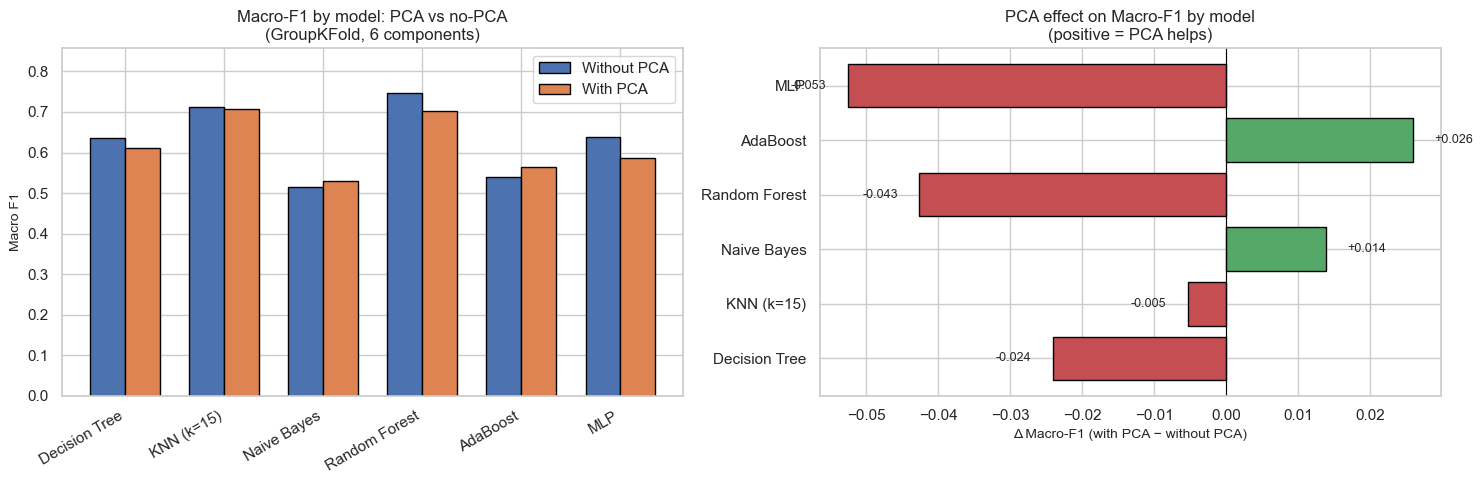

In [432]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Side-by-side bar chart of F1 scores
x_pos = np.arange(len(pca_df))
width = 0.35
axes[0].bar(x_pos - width/2, pca_df["_f1_no"], width,
            label="Without PCA", color="#4C72B0", edgecolor="black")
axes[0].bar(x_pos + width/2, pca_df["_f1_yes"], width,
            label="With PCA", color="#DD8452", edgecolor="black")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(pca_df["model"], rotation=30, ha="right")
axes[0].set_ylabel("Macro F1")
axes[0].set_title(f"Macro-F1 by model: PCA vs no-PCA\n(GroupKFold, {n_components_used} components)")
axes[0].set_ylim(0, max(pca_df["_f1_no"].max(), pca_df["_f1_yes"].max()) * 1.15)
axes[0].legend()

# Delta plot
colors = ["#55A868" if d > 0 else "#C44E52" for d in pca_df["_delta_f1"]]
axes[1].barh(pca_df["model"], pca_df["_delta_f1"], color=colors, edgecolor="black")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Δ Macro-F1 (with PCA − without PCA)")
axes[1].set_title("PCA effect on Macro-F1 by model\n(positive = PCA helps)")
for i, d in enumerate(pca_df["_delta_f1"]):
    label_x = d + (0.003 if d >= 0 else -0.003)
    align = "left" if d >= 0 else "right"
    axes[1].text(label_x, i, f"{d:+.3f}", va="center", ha=align, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "pca_comparison.pdf", bbox_inches="tight")
plt.show()